# Phase 1 — Scaleup Image-Only Classifier
## PneumoFusionNet | MIMIC-CXR PA Cohort (Scaled-Up Dataset: 3,763 images)

Same architecture as Phase 1.1v6, now trained on the expanded balanced dataset:
- **3,763 total PA images** (1,891 Pneumonia + 1,872 Normal)
- **DenseNet121** backbone with MIMIC-specific weights (`densenet121-res224-mimic_nb`)
- **CBAM attention** (Channel + Spatial)
- **Otsu-based lung bbox detection** at 320×320 resolution
- **Label smoothing (0.1)**, **TTA (10 views)**, **CosineAnnealingWarmRestarts**
- **Patient-level splitting** (stratified 70/15/15 by `subject_id`) to prevent data leakage

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, sys, random, warnings, json, copy, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
print(f'PyTorch : {torch.__version__}')
print(f'XRV     : {xrv.__version__}')

Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.29 GB
PyTorch : 2.5.1+cu121
XRV     : 1.4.0


In [2]:
# --- CELL 1: Configuration ---
BASE_DIR   = r'c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1_Scaleup_PA')
os.makedirs(SAVE_DIR, exist_ok=True)

# Backbone: MIMIC-specific weights
BACKBONE_WEIGHTS = 'densenet121-res224-mimic_nb'

# Higher resolution for subtle opacity patterns
IMG_SIZE   = 320

# Training hyperparameters
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 40
PATIENCE     = 10
TTA_VIEWS    = 10
LABEL_SMOOTH = 0.1
CLASSES      = ['NORMAL', 'PNEUMONIA']

# Tuned CLAHE
CLAHE_CLIP  = 3.0
CLAHE_TILE  = (4,4)

print(f'Backbone weights : {BACKBONE_WEIGHTS}')
print(f'Image resolution : {IMG_SIZE}x{IMG_SIZE}')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'Save dir         : {SAVE_DIR}')

Backbone weights : densenet121-res224-mimic_nb
Image resolution : 320x320
Label smoothing  : 0.1
Save dir         : c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA


In [3]:
# --- CELL 2: Data Loading & Label Assignment ---
df = pd.read_csv(CSV_PATH)

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '': return ''
    p = str(p).replace('/', os.sep)
    return p if os.path.isabs(p) else os.path.join(BASE_DIR, p)

df['image_path'] = df['image_path'].apply(resolve_path)
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0], default=-1
)
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'Total usable PA rows : {len(df)}')
print(df['label'].value_counts().rename({0:'Normal',1:'Pneumonia'}))

Total usable PA rows : 3763
Pneumonia    1891
Normal       1872
Name: label, dtype: int64


In [4]:
# --- CELL 3: Otsu-based Lung Bbox Detection (100% image coverage) ---
def detect_lung_bbox_otsu(image_path, margin=0.05):
    """
    Detect lung bounding box using Otsu thresholding + morphological operations.
    Returns dict with x_min, y_min, x_max, y_max, or None if detection fails.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    H, W = img.shape

    # CLAHE + Gaussian blur for better thresholding
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_c = clahe.apply(img)
    blurred = cv2.GaussianBlur(img_c, (5,5), 0)

    # Otsu threshold
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing to fill holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,20))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Find contours — take the largest one (lung field)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < (H * W * 0.10): return None  # too small -- reject

    x,y,w,h = cv2.boundingRect(largest)
    # Add margin
    mx = int(W * margin); my = int(H * margin)
    x_min = max(0, x - mx)
    y_min = max(0, y - my)
    x_max = min(W, x + w + mx)
    y_max = min(H, y + h + my)
    return {'x_min':x_min,'y_min':y_min,'x_max':x_max,'y_max':y_max}

# Check for cached bboxes from prior runs
bbox_cache_path = os.path.join(SAVE_DIR, 'lung_bboxes_scaleup.csv')
if os.path.exists(bbox_cache_path):
    old_bbox_df = pd.read_csv(bbox_cache_path)
    bbox_lookup = old_bbox_df.set_index('image_path').to_dict('index')
    print(f'Loaded {len(bbox_lookup)} cached bboxes from prior run')
else:
    bbox_lookup = {}
    print('No cached bboxes found, will detect from scratch')

missing_paths = [row.image_path for _, row in df.iterrows() if row.image_path not in bbox_lookup]
print(f'Images needing new bbox detection: {len(missing_paths)}')

detected, failed = 0, 0
for path in tqdm(missing_paths, desc='Detecting lung bboxes'):
    bb = detect_lung_bbox_otsu(path)
    if bb:
        bbox_lookup[path] = bb
        detected += 1
    else:
        failed += 1

print(f'Detected  : {detected}')
print(f'Failed    : {failed} (will use full image)')
print(f'Total bbox coverage: {len(bbox_lookup)}/{len(df)} ({len(bbox_lookup)/len(df)*100:.1f}%)')

# Save/update bbox cache
bbox_rows = [{'image_path':k,'x_min':v['x_min'],'y_min':v['y_min'],
               'x_max':v['x_max'],'y_max':v['y_max']} for k,v in bbox_lookup.items()]
pd.DataFrame(bbox_rows).to_csv(bbox_cache_path, index=False)
print(f'Saved bbox cache: {bbox_cache_path}')

Loaded 3763 cached bboxes from prior run
Images needing new bbox detection: 0


Detecting lung bboxes: 0it [00:00, ?it/s]

Detected  : 0
Failed    : 0 (will use full image)
Total bbox coverage: 3763/3763 (100.0%)
Saved bbox cache: c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA\lung_bboxes_scaleup.csv


In [5]:
# --- CELL 4: Patient-Level Train / Val / Test Split (70/15/15) ---
# Group by subject_id to prevent data leakage across splits
subject_ids = df['subject_id'].unique()
train_val_sids, test_sids = train_test_split(subject_ids, test_size=0.15, random_state=SEED)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_sids, val_sids = train_test_split(train_val_sids, test_size=val_frac, random_state=SEED)

train_df = df[df['subject_id'].isin(train_sids)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_sids)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_sids)].reset_index(drop=True)

for name, split in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    n0=(split['label']==0).sum(); n1=(split['label']==1).sum()
    print(f'{name:5s}: {len(split):5d}  (Normal={n0}, Pneumonia={n1})')

Train:  2624  (Normal=1311, Pneumonia=1313)
Val  :   557  (Normal=278, Pneumonia=279)
Test :   582  (Normal=283, Pneumonia=299)


In [6]:
# --- CELL 5: Compute Dataset Mean & Std (for 320x320) ---
sample_paths = train_df['image_path'].sample(min(300, len(train_df)), random_state=SEED).tolist()
clahe_stat   = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
pixel_vals   = []
for p in tqdm(sample_paths, desc='Computing stats'):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    img = clahe_stat.apply(img)
    bb  = bbox_lookup.get(p, None)
    if bb and bb.get('x_max',0)>0:
        img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    pixel_vals.append(img.flatten())
all_pixels = np.concatenate(pixel_vals)
MEAN = [float(all_pixels.mean())]
STD  = [float(all_pixels.std())]
print(f'Computed MEAN: {MEAN[0]:.4f}  STD: {STD[0]:.4f}')

Computing stats:   0%|          | 0/300 [00:00<?, ?it/s]

Computed MEAN: 0.4991  STD: 0.2829


In [7]:
# --- CELL 6: Enhanced Dataset Class ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform, clahe_clip=CLAHE_CLIP, clahe_tile=CLAHE_TILE):
        self.df          = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform   = transform
        self.clahe       = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8)
        # Tuned CLAHE
        img = self.clahe.apply(img)
        # Bbox crop
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max',0)>0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = self.transform(Image.fromarray(img))
        return img, int(row.label)
    def set_transform(self, t): self.transform = t

# Transforms (320x320)
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# TTA transforms (10 views)
tta_tfms = [
    val_tfm,
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomHorizontalFlip(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.1),int(IMG_SIZE*1.1))),
                         transforms.CenterCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(5,5)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(-5,-5)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(brightness=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(contrast=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.05),int(IMG_SIZE*1.05))),
                         transforms.RandomCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomAutocontrast(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomEqualize(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
]

train_ds = EnhancedCXRDataset(train_df, bbox_lookup, train_tfm)
val_ds   = EnhancedCXRDataset(val_df,   bbox_lookup, val_tfm)
test_ds  = EnhancedCXRDataset(test_df,  bbox_lookup, val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 164 | Val: 35 | Test: 37


In [8]:
# --- CELL 7: Model Architecture (DenseNet121 + CBAM) ---

# ---- CBAM attention modules ----
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.mlp=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.mlp(self.avg(x))+self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

# ---- Main model ----
class ScaleupCXRModel(nn.Module):
    def __init__(self, backbone_weights=BACKBONE_WEIGHTS, num_classes=2):
        super().__init__()
        # MIMIC-specific weights
        xrv_m = xrv.models.DenseNet(weights=backbone_weights)
        self.features = xrv_m.features
        self.cbam     = CBAM(1024, r=16)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.dropout  = nn.Dropout(0.4)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        # Only freeze denseblock1 + transition1
        freeze_prefixes = ('features.conv0','features.norm0','features.relu0',
                           'features.pool0','features.denseblock1','features.transition1')
        for name, param in self.features.named_parameters():
            pname = 'features.' + name
            if any(pname.startswith(pfx) for pfx in freeze_prefixes):
                param.requires_grad = False

        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'[Model] Total params     : {total:,}')
        print(f'[Model] Trainable params : {trainable:,} ({trainable/total*100:.1f}%)')

    def forward(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        f = self.dropout(self.pool(f).flatten(1))
        return self.classifier(f)

    def get_features(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        return self.pool(f).flatten(1)  # (B, 1024) for downstream fusion

print(f'Loading backbone: {BACKBONE_WEIGHTS} ...')
model = ScaleupCXRModel().to(DEVICE)

Loading backbone: densenet121-res224-mimic_nb ...
[Model] Total params     : 7,670,500
[Model] Trainable params : 7,298,916 (95.2%)


In [9]:
# --- CELL 8: Training Setup ---

# Class-weighted loss + label smoothing
n0=(train_df['label']==0).sum(); n1=(train_df['label']==1).sum()
weight = torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=LABEL_SMOOTH)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            probs = F.softmax(logits.detach(), dim=1)[:,1].cpu().numpy()
            total_loss += loss.item()*labels.size(0)
            all_probs.extend(probs); all_labels.extend(labels.cpu().tolist())
    acc = accuracy_score(all_labels,[1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc

print('Training setup complete.')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'LR               : {LR}')
print(f'Scheduler        : CosineAnnealingWarmRestarts (T_0=10)')

Training setup complete.
Label smoothing  : 0.1
LR               : 0.0001
Scheduler        : CosineAnnealingWarmRestarts (T_0=10)


In [10]:
# --- CELL 9: Training Loop (WITH RESUME SUPPORT) ---
ckpt_path = os.path.join(SAVE_DIR, 'latest_checkpoint_scaleup.pth')
start_epoch = 1

best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'lr':[]}

if os.path.exists(ckpt_path):
    print(f'>> Found checkpoint: {ckpt_path}. Resuming training...')
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start_epoch = ckpt['epoch'] + 1
    best_auc = ckpt['best_auc']
    history = ckpt['history']
    patience_cnt = ckpt['patience_cnt']
    best_state = copy.deepcopy(model.state_dict())
    print(f'>> Resuming from Epoch {start_epoch} (Best AUC so far: {best_auc:.4f})')

t0 = time.time()
for epoch in range(start_epoch, EPOCHS+1):
    ep_t = time.time()
    tr_loss, tr_acc, tr_auc = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    va_loss, va_acc, va_auc = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(va_auc)
    history['lr'].append(cur_lr)

    marker = ''
    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(SAVE_DIR,'best_model_scaleup.pth'))
        patience_cnt = 0; marker = ' <-- best'
    else:
        patience_cnt += 1

    # Save resume checkpoint
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_auc': best_auc,
        'history': history,
        'patience_cnt': patience_cnt
    }, ckpt_path)
    elapsed  = time.time() - t0
    ep_time  = time.time() - ep_t
    remaining= ep_time * (EPOCHS - epoch)
    if epoch % 5 == 0 or marker:
        print(f'Ep {epoch:03d}/{EPOCHS} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} '
              f'| val_auc={va_auc:.4f} val_acc={va_acc:.3f} '
              f'| lr={cur_lr:.1e} | {ep_time:.0f}s/ep | ETA:{remaining/60:.0f}m{marker}')

    if patience_cnt >= PATIENCE:
        print(f'Early stop at epoch {epoch}.'); break

print(f'Training complete in {(time.time()-t0)/60:.1f} min')
print(f'Best Val AUC: {best_auc:.4f}')

>> Found checkpoint: c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA\latest_checkpoint_scaleup.pth. Resuming training...
>> Resuming from Epoch 3 (Best AUC so far: 0.7619)
Ep 003/40 | tr_loss=0.5213 tr_auc=0.8637 | val_auc=0.7653 val_acc=0.686 | lr=8.0e-05 | 298s/ep | ETA:184m <-- best
Ep 005/40 | tr_loss=0.6285 tr_auc=0.7376 | val_auc=0.7698 val_acc=0.697 | lr=5.1e-05 | 252s/ep | ETA:147m <-- best
Ep 006/40 | tr_loss=0.6140 tr_auc=0.7550 | val_auc=0.7699 val_acc=0.704 | lr=3.5e-05 | 242s/ep | ETA:137m <-- best
Ep 007/40 | tr_loss=0.6230 tr_auc=0.7390 | val_auc=0.7730 val_acc=0.704 | lr=2.1e-05 | 244s/ep | ETA:134m <-- best
Ep 010/40 | tr_loss=0.6071 tr_auc=0.7638 | val_auc=0.7725 val_acc=0.706 | lr=1.0e-04 | 239s/ep | ETA:120m
Ep 011/40 | tr_loss=0.6052 tr_auc=0.7637 | val_auc=0.7775 val_acc=0.704 | lr=9.9e-05 | 240s/ep | ETA:116m <-- best
Ep 012/40 | tr_loss=0.6039 tr_auc=0.7649 | val_auc=0.7880 val_acc=0.716 | lr=9.8e-05 | 296s/ep | ETA:138m <-- best
Ep 01

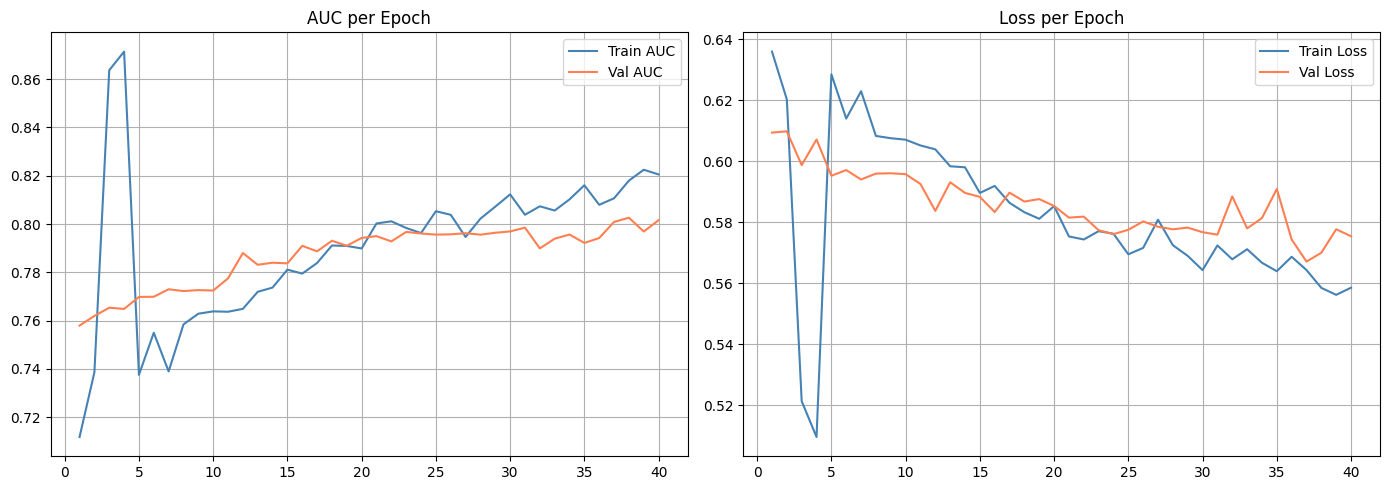

In [11]:
# --- CELL 10: Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_auc'])+1)

axes[0].plot(epochs_range, history['train_auc'], label='Train AUC', color='steelblue')
axes[0].plot(epochs_range, history['val_auc'],   label='Val AUC',   color='coral')
axes[0].set_title('AUC per Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='coral')
axes[1].set_title('Loss per Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_scaleup.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- CELL 11: Test Evaluation with TTA (10 views) ---
model.load_state_dict(best_state)
model.eval()

all_tta_probs = []
for tfm in tqdm(tta_tfms, desc='TTA views'):
    test_ds.set_transform(tfm)
    probs_view = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            logits = model(imgs.to(DEVICE))
            probs_view.extend(F.softmax(logits, dim=1)[:,1].cpu().numpy())
    all_tta_probs.append(probs_view)

tta_probs  = np.mean(all_tta_probs, axis=0)
true_labels = test_df['label'].values

# Clinical threshold: maximise Sensitivity >= 90%
fpr, tpr, thresholds = roc_curve(true_labels, tta_probs)
high_sens = [(t, tpr[i], 1-fpr[i]) for i,t in enumerate(thresholds) if tpr[i] >= 0.90]
best_thresh = max(high_sens, key=lambda x: x[2])[0] if high_sens else 0.5

preds = (tta_probs >= best_thresh).astype(int)
auc   = roc_auc_score(true_labels, tta_probs)
acc   = accuracy_score(true_labels, preds)
f1    = f1_score(true_labels, preds)
cm    = confusion_matrix(true_labels, preds)
tn, fp, fn, tp = cm.ravel()
sens  = tp / (tp + fn)
spec  = tn / (tn + fp)

print('='*55)
print(f'  Test Results (TTA={TTA_VIEWS}, threshold={best_thresh:.3f})')
print('='*55)
print(f'  AUC         : {auc:.4f}')
print(f'  Accuracy    : {acc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  Sensitivity : {sens:.4f}  (Recall for Pneumonia)')
print(f'  Specificity : {spec:.4f}  (Recall for Normal)')
print('='*55)
print(classification_report(true_labels, preds, target_names=CLASSES))

TTA views:   0%|          | 0/10 [00:00<?, ?it/s]

  Test Results (TTA=10, threshold=0.303)
  AUC         : 0.8009
  Accuracy    : 0.6375
  F1-Score    : 0.7198
  Sensitivity : 0.9064  (Recall for Pneumonia)
  Specificity : 0.3534  (Recall for Normal)
              precision    recall  f1-score   support

      NORMAL       0.78      0.35      0.49       283
   PNEUMONIA       0.60      0.91      0.72       299

    accuracy                           0.64       582
   macro avg       0.69      0.63      0.60       582
weighted avg       0.69      0.64      0.61       582



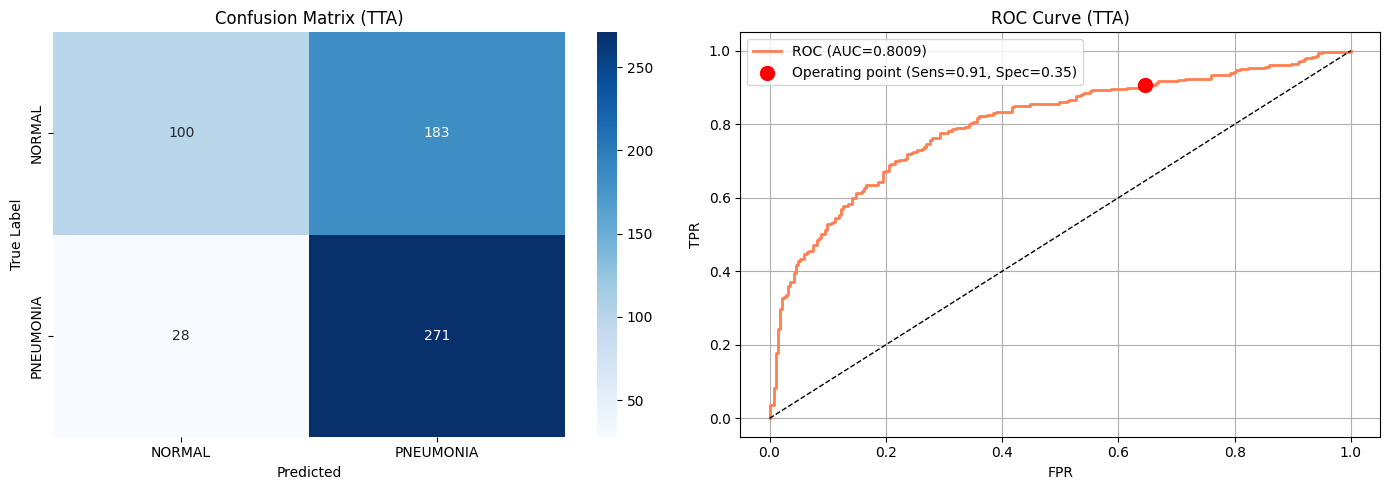

Results saved to: c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA


In [13]:
# --- CELL 12: Confusion Matrix & ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (TTA)')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, color='coral', lw=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].scatter([1-spec],[sens], color='red', s=100, zorder=5,
                label=f'Operating point (Sens={sens:.2f}, Spec={spec:.2f})')
axes[1].set_title('ROC Curve (TTA)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'results_scaleup.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Results saved to: {SAVE_DIR}')

In [14]:
# --- CELL 13: Save Final Results JSON ---
results = {
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'auc': float(auc),
    'accuracy': float(acc),
    'f1': float(f1),
    'sensitivity': float(sens),
    'specificity': float(spec),
    'threshold': float(best_thresh),
    'tta_views': TTA_VIEWS,
    'best_val_auc': float(best_auc),
    'backbone': BACKBONE_WEIGHTS,
    'img_size': IMG_SIZE,
}
with open(os.path.join(SAVE_DIR, 'results_scaleup.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved:')
for k,v in results.items():
    print(f'  {k}: {v}')

Results saved:
  dataset_size: 3763
  train_size: 2624
  val_size: 557
  test_size: 582
  auc: 0.8009147098100855
  accuracy: 0.6374570446735395
  f1: 0.7197875166002655
  sensitivity: 0.9063545150501672
  specificity: 0.35335689045936397
  threshold: 0.3029167056083679
  tta_views: 10
  best_val_auc: 0.8025966323715221
  backbone: densenet121-res224-mimic_nb
  img_size: 320
